In [12]:
import numpy as np
from PIL import Image

In [16]:
p1=Image.open(r"C:\Users\癌坤\Pictures\Screenshots\屏幕截图 2026-10-02 111919.png").convert("RGB")

In [17]:
p2=Image.open(r"C:\Users\癌坤\Pictures\Screenshots\屏幕截图 2026-10-02 111919.png").convert("L")

In [18]:
fp1=np.array(p1)
fp2=np.array(p2)

In [19]:
print(fp1.shape)
print(fp1.dtype)
print(fp1.max())
print(fp1.min())

(455, 791, 3)
uint8
255
19


In [20]:
print(fp2.shape)
print(fp2.dtype)
print(fp2.max())
print(fp2.min())

(455, 791)
uint8
255
21


In [24]:
import numpy as np

kernel= np.array([
    [ 0, -1, 0],
    [-1, 5, -1],
    [ 0, -1, 0],
], dtype=np.float32)


In [25]:
import numpy as np

def conv2d_gray(fp2:np.ndarray, kernel:np.ndarray):
    H_in, W_in = fp2.shape
    k_h, k_w = kernel.shape
    H_out = H_in - k_h + 1
    W_out = W_in - k_w + 1

    output = np.zeros((H_out, W_out), dtype=np.float32)

    # 双重循环滑动卷积核
    for i in range(H_out):
        for j in range(W_out):
            patch = fp2[i : i + k_h, j : j + k_w]
            value = np.sum(patch * kernel)
            output[i, j] = value
    return output


D:\conda_envs\ai\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\conda_envs\ai\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\conda_envs\ai\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23610 (\N{CJK UNIFIED IDEOGRAPH-5C3A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\conda_envs\ai\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23544 (\N{CJK UNIFIED IDEOGRAPH-5BF8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\conda_envs\ai\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\con

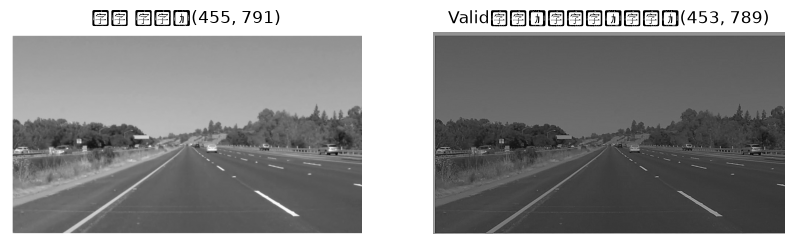

In [26]:
import matplotlib.pyplot as plt

# 使用你原来没有padding的conv2d_gray（会裁掉一圈）
conv_result = conv2d_gray(fp2, kernel)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(fp2, cmap='gray')
plt.title(f"原图 尺寸：{fp2.shape}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(np.abs(conv_result), cmap='gray')
plt.title(f"Valid卷积（裁一圈）尺寸：{conv_result.shape}")
plt.axis('off')

plt.show()
